In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [4]:
# Define the file path (adjust if your notebook is not in a subfolder)
file_path = '../data/raw/medeasy_cleaned_database.csv'

# Load the dataset
df = pd.read_csv(file_path)

# Display shape and basic info
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("-" * 40)
print("Data Types and Non-Null Counts:")
print(df.info())
print("-" * 40)

# Display the first 5 rows
display(df.head())

Dataset Shape: 2544 rows, 24 columns

----------------------------------------
Data Types and Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 2544 entries, 0 to 2543
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   medicine_name       2544 non-null   str    
 1   strength            1897 non-null   str    
 2   dosage_form         2460 non-null   str    
 3   generic_name        2460 non-null   str    
 4   manufacturer        2542 non-null   str    
 5   mrp                 2544 non-null   float64
 6   discounted_price    2544 non-null   float64
 7   pack_size           415 non-null    float64
 8   pack_type           415 non-null    str    
 9   indications         2544 non-null   str    
 10  dosage              2544 non-null   str    
 11  administration      2544 non-null   str    
 12  interactions        2544 non-null   str    
 13  contraindications   2544 non-null   str    
 14  side

,medicine_name,strength,dosage_form,generic_name,manufacturer,mrp,discounted_price,pack_size,pack_type,indications,...,side_effects,precautions,overdose_effects,storage_conditions,mode_of_action,pregnancy_info,pediatric_use,disclaimer,alternatives,source_url
0,Xinc-B100 ml,100 ml,Syrup,Vitamin B Complex + Zinc,Eskayef Bangladesh Ltd.,65.0,65.00,NaN,NaN,Information not provided.,...,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Disclaimer The information provided is accurat...,bottle,https://medeasy.health/medicines/xinc-b-100-ml...
1,Flatameal DS(200 mg+400 mg+30 mg)/5 ml,200 mg,Suspension,Aluminium Hydroxide + Magnesium Hydroxide + Si...,Beximco Pharmaceuticals Ltd.,75.0,75.00,NaN,NaN,Information not provided.,...,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Disclaimer The information provided is accurat...,Stock,https://medeasy.health/medicines/flatameal-ds-...
2,Becoral D,NaN,Tablet,Calcium Carbonate [Coral Source] + Vitamin D3,Beximco Pharmaceuticals Ltd.,100.0,100.00,10.0,Strip,Information not provided.,...,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Disclaimer The information provided is accurat...,Information not provided.,https://medeasy.health/medicines/becoral-d-tablet
3,Irobest,NaN,Tablet,Iron Polymaltose Complex + Folic Acid + Zinc S...,Nipro Jmi Pharma Ltd.,35.0,35.00,10.0,Strip,Information not provided.,...,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Information not provided.,Disclaimer The information provided is accurat...,Information not provided.,https://medeasy.health/medicines/irobest-47-mg...
4,Filmet400 mg,400 mg,Tablet,Metronidazole,Beximco Pharmaceuticals Ltd.,1.7,1.56,NaN,NaN,Indications of Filmet 400 mg Filmet 400 mg is ...,...,"Side Effects of Filmet 400 mg Metallic taste, ...",Precautions & Warnings If for compelling reaso...,Overdose Effects of Filmet 400 mg Single oral ...,Storage Conditions Store below 30°C. Keep prot...,Mode Of Action Filmet 400 mg is a member of th...,Pregnancy & Lactation US FDA Pregnancy Categor...,Pediatric Uses Hepatic impairment: Filmet 400 ...,Disclaimer The information provided is accurat...,50 | Micogyl | of | Flagyl | 200-40 | Metryl |...,https://medeasy.health/medicines/filmet-400-mg...


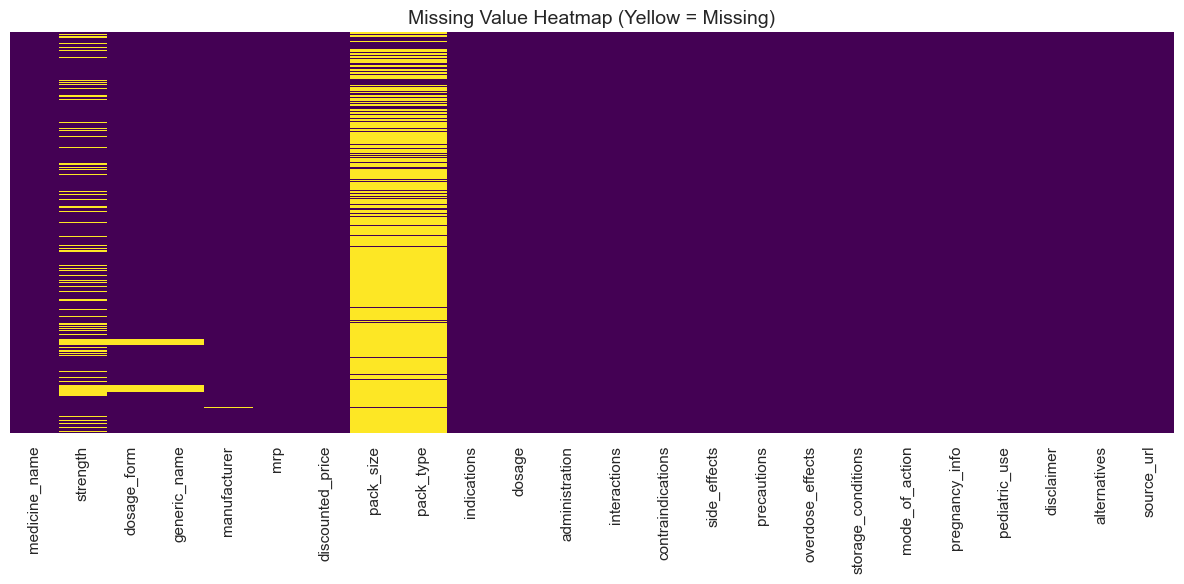

Top 5 columns with highest missing values:
pack_size       2129
pack_type       2129
strength         647
generic_name      84
dosage_form       84
dtype: int64


In [5]:
# Plot a heatmap of null values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow = Missing)', fontsize=14)
plt.tight_layout()
plt.show()

# Print exact null counts for the most sparse columns
print("Top 5 columns with highest missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(5))

C:\Users\hosse\AppData\Local\Temp\ipykernel_6944\3124331276.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dosage_counts.values, y=dosage_counts.index, palette='Blues_r')


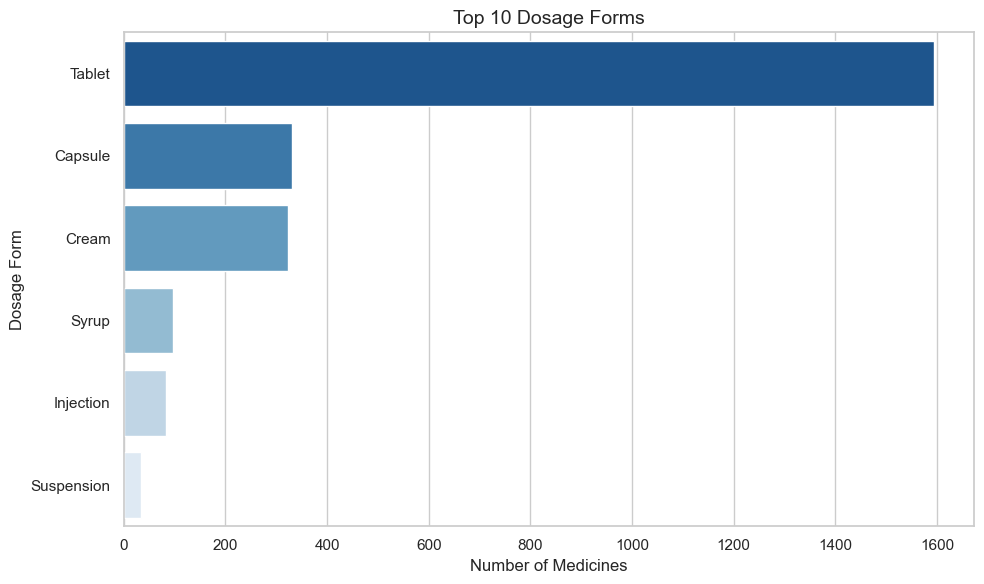

In [6]:
# Plot top 10 dosage forms
plt.figure(figsize=(10, 6))
dosage_counts = df['dosage_form'].value_counts().head(10)
sns.barplot(x=dosage_counts.values, y=dosage_counts.index, palette='Blues_r')

plt.title('Top 10 Dosage Forms', fontsize=14)
plt.xlabel('Number of Medicines')
plt.ylabel('Dosage Form')
plt.tight_layout()
plt.show()

C:\Users\hosse\AppData\Local\Temp\ipykernel_6944\4284997782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=manufacturer_counts.values, y=manufacturer_counts.index, palette='crest')


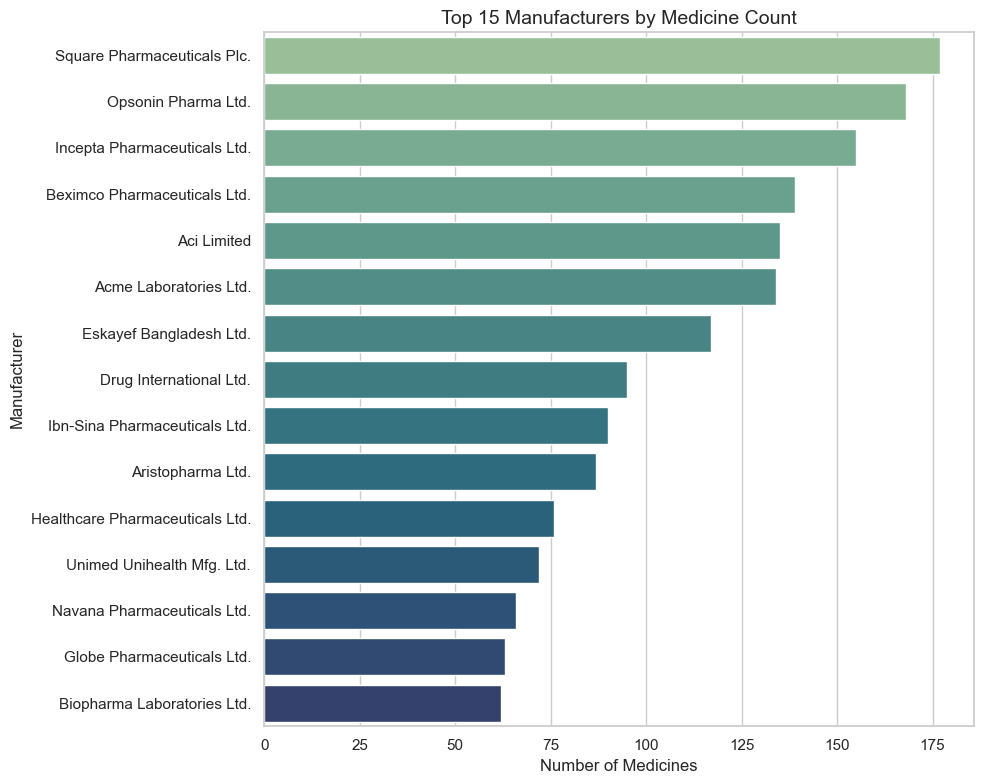

In [7]:
# Plot top 15 manufacturers
plt.figure(figsize=(10, 8))
manufacturer_counts = df['manufacturer'].value_counts().head(15)
sns.barplot(x=manufacturer_counts.values, y=manufacturer_counts.index, palette='crest')

plt.title('Top 15 Manufacturers by Medicine Count', fontsize=14)
plt.xlabel('Number of Medicines')
plt.ylabel('Manufacturer')
plt.tight_layout()
plt.show()

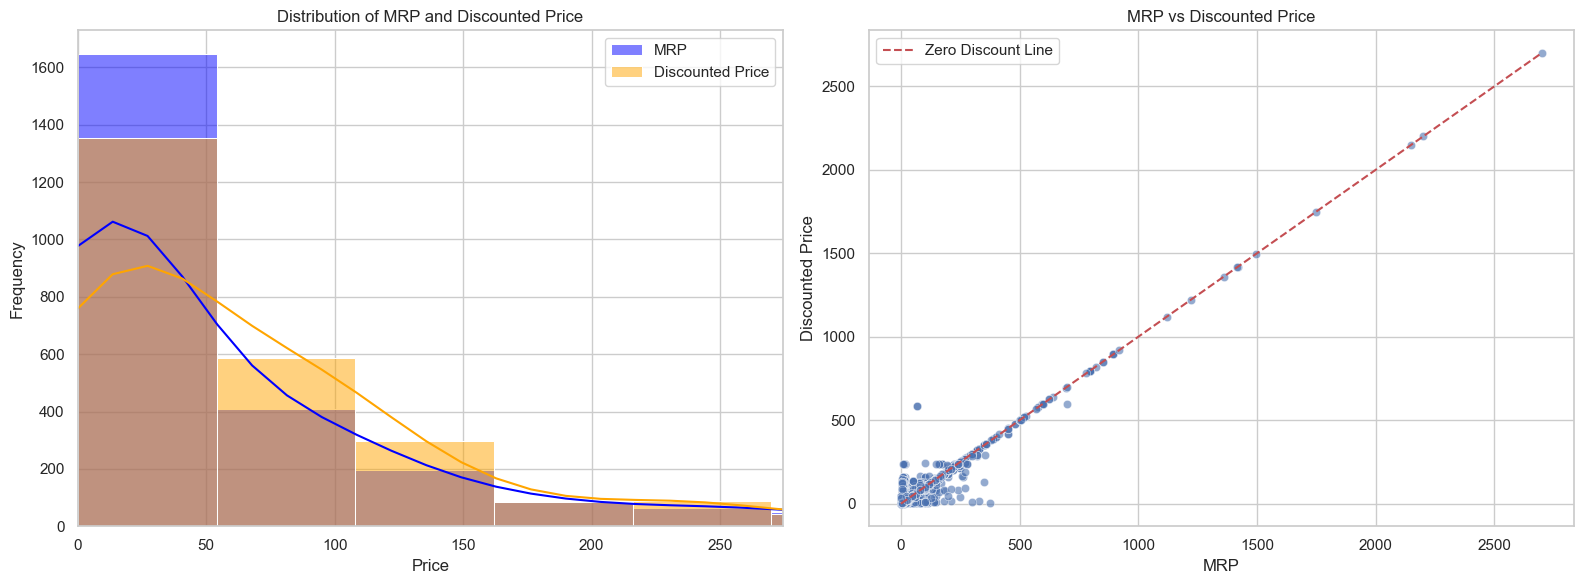

In [8]:
# Create a figure with two subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Price Distributions (Histograms)
sns.histplot(df['mrp'], bins=50, color='blue', alpha=0.5, label='MRP', ax=axes[0], kde=True)
sns.histplot(df['discounted_price'], bins=50, color='orange', alpha=0.5, label='Discounted Price', ax=axes[0], kde=True)
axes[0].set_title('Distribution of MRP and Discounted Price')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
# Limit x-axis to 95th percentile to handle massive outliers for better visualization
axes[0].set_xlim(0, df['mrp'].quantile(0.95)) 
axes[0].legend()

# Subplot 2: Scatter plot of MRP vs Discounted Price
sns.scatterplot(x='mrp', y='discounted_price', data=df, alpha=0.6, ax=axes[1])
axes[1].set_title('MRP vs Discounted Price')
axes[1].set_xlabel('MRP')
axes[1].set_ylabel('Discounted Price')

# Add a y=x reference line
max_price = max(df['mrp'].max(), df['discounted_price'].max())
axes[1].plot([0, max_price], [0, max_price], 'r--', label='Zero Discount Line')
axes[1].legend()

plt.tight_layout()
plt.show()

In [9]:
# Define text columns to check
text_columns = ['indications', 'side_effects', 'mode_of_action', 'alternatives'] 
# Note: Add any other specific text columns from your 24 cols if needed

placeholder_text = "Information not provided."
missing_info_counts = {}

for col in text_columns:
    if col in df.columns:
        # Count exact matches (stripping whitespace and ignoring case just to be safe)
        count = df[col].astype(str).str.strip().str.lower() == placeholder_text.lower()
        missing_info_counts[col] = count.sum()

# Display the results
print("Count of rows containing 'Information not provided.':")
for col, count in missing_info_counts.items():
    percentage = (count / len(df)) * 100
    print(f"- {col}: {count} rows ({percentage:.1f}%)")

Count of rows containing 'Information not provided.':
- indications: 955 rows (37.5%)
- side_effects: 963 rows (37.9%)
- mode_of_action: 1292 rows (50.8%)
- alternatives: 797 rows (31.3%)


C:\Users\hosse\AppData\Local\Temp\ipykernel_6944\2885009010.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=generic_counts.values, y=generic_counts.index, palette='magma')


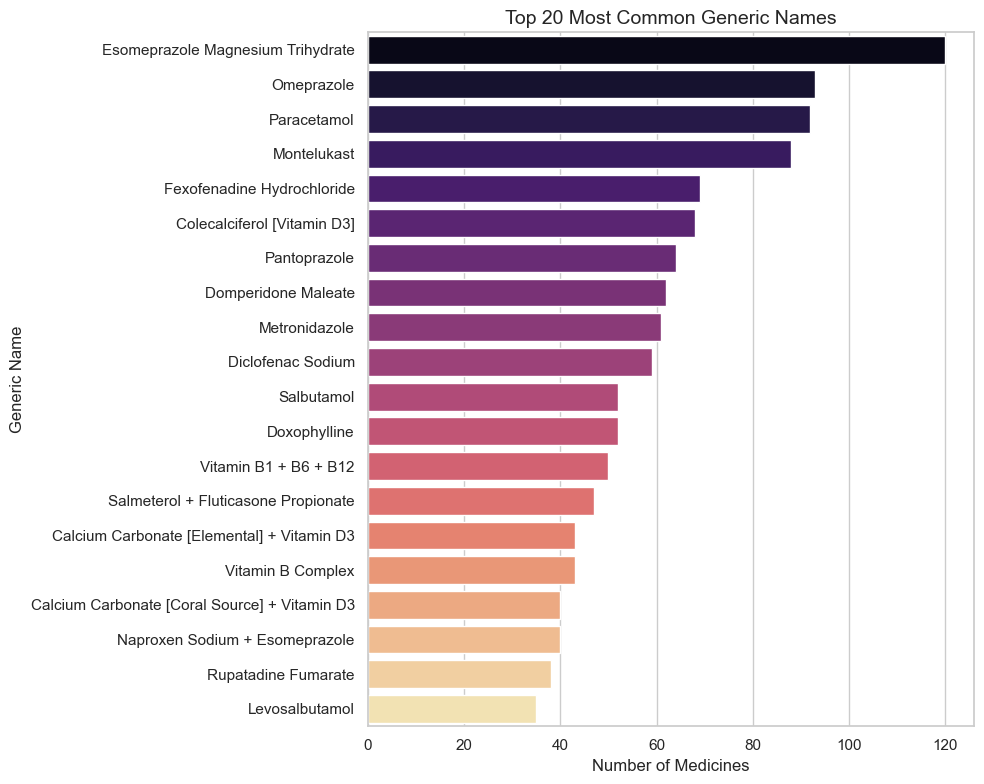

In [10]:
# Plot top 20 generic names
plt.figure(figsize=(10, 8))
generic_counts = df['generic_name'].value_counts().head(20)
sns.barplot(x=generic_counts.values, y=generic_counts.index, palette='magma')

plt.title('Top 20 Most Common Generic Names', fontsize=14)
plt.xlabel('Number of Medicines')
plt.ylabel('Generic Name')
plt.tight_layout()
plt.show()

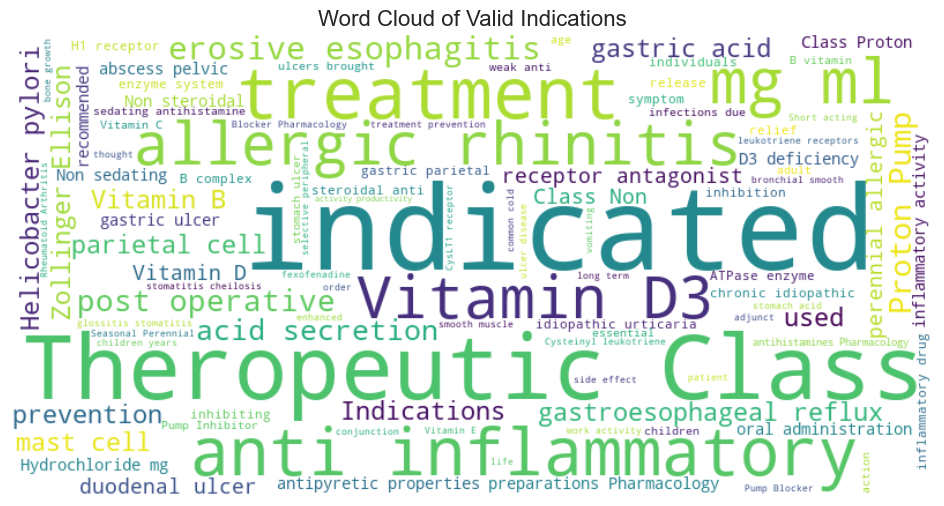

In [11]:
# Filter out nulls and placeholder text
valid_indications = df['indications'].dropna()
valid_indications = valid_indications[
    valid_indications.str.strip().str.lower() != placeholder_text.lower()
]

# Join all text into a single string
text_data = " ".join(valid_indications)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white', 
                      colormap='viridis',
                      max_words=100).generate(text_data)

# Display the generated image
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Valid Indications', fontsize=16)
plt.show()

C:\Users\hosse\AppData\Local\Temp\ipykernel_6944\3254568088.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns
C:\Users\hosse\AppData\Local\Temp\ipykernel_6944\3254568088.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Avg Character Length', y='Feature', data=length_df, palette='flare')


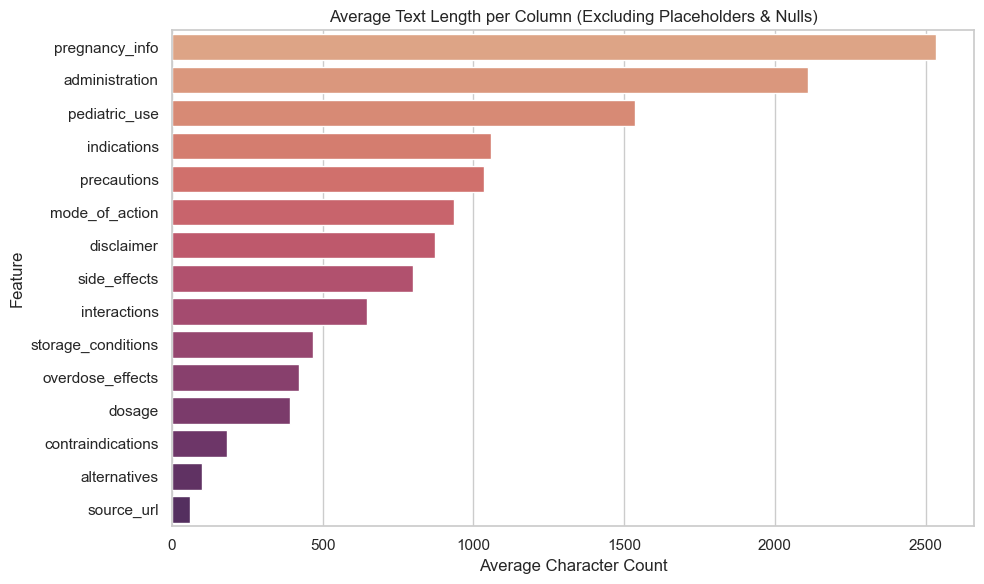

In [12]:
# Select object/string columns that are likely to contain paragraphs of text
text_cols = df.select_dtypes(include=['object']).columns
# Filter out categorical/short string columns
text_cols = [col for col in text_cols if col not in ['medicine_name', 'generic_name', 'dosage_form', 'manufacturer', 'pack_type', 'strength']]

avg_lengths = {}

for col in text_cols:
    # Get series of valid strings (not null, and not the placeholder)
    valid_texts = df[col].dropna()
    valid_texts = valid_texts[valid_texts.str.strip().str.lower() != placeholder_text.lower()]
    
    if len(valid_texts) > 0:
        # Calculate mean character length
        avg_lengths[col] = valid_texts.apply(len).mean()

# Convert to DataFrame for plotting
length_df = pd.DataFrame(list(avg_lengths.items()), columns=['Feature', 'Avg Character Length'])
length_df = length_df.sort_values(by='Avg Character Length', ascending=False)

# Plot average text length
plt.figure(figsize=(10, 6))
sns.barplot(x='Avg Character Length', y='Feature', data=length_df, palette='flare')
plt.title('Average Text Length per Column (Excluding Placeholders & Nulls)')
plt.xlabel('Average Character Count')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()